In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [2]:
DATASET_DIR = "../data/images"

print("Dataset path:", os.path.abspath(DATASET_DIR))

Dataset path: C:\Users\senay\Documents\stray-animal-ai-project\data\images


In [3]:
print(os.listdir(DATASET_DIR))

[]


In [4]:
print(os.listdir(DATASET_DIR))

['Critical', 'Healthy', 'Injured', 'Sick']


In [5]:
import os

DATASET_DIR = "../data/images"

print(os.path.abspath(DATASET_DIR))
print(os.listdir(DATASET_DIR))

C:\Users\senay\Documents\stray-animal-ai-project\data\images
['Critical', 'Healthy', 'Injured', 'Sick']


In [6]:
for folder in os.listdir(DATASET_DIR):
    folder_path = os.path.join(DATASET_DIR, folder)

    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)

        print(folder, ":", len(images), "images")

Critical : 1 images
Healthy : 2 images
Injured : 2 images
Sick : 2 images


In [7]:
for folder in os.listdir(DATASET_DIR):
    folder_path = os.path.join(DATASET_DIR, folder)

    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        print(folder, ":", len(images), "images")

Critical : 1 images
Healthy : 8 images
Injured : 6 images
Sick : 3 images


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 13 files belonging to 4 classes.
Using 11 files for training.


In [10]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 13 files belonging to 4 classes.
Using 2 files for validation.


In [11]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Classes:
['Critical', 'Healthy', 'Injured', 'Sick']


In [12]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, JPEG XL, PNG, GIF, BMP, WebP required.
	 [[{{node decode_image/DecodeImage}}]] [Op:IteratorGetNext] name: 

<Figure size 1000x1000 with 0 Axes>

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [14]:
import os
from PIL import Image

DATASET_DIR = "../data/images"

for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(DATASET_DIR, folder)

    if not os.path.isdir(folder_path):
        continue

    print("\nChecking:", folder)

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        try:
            with Image.open(file_path) as img:
                img.verify()

            print("OK:", filename)

        except Exception as e:
            print("BAD:", filename)
            print("    Error:", e)


Checking: Critical
OK: accident_dog.jpg

Checking: Healthy
OK: cat.jpg
OK: dog.jpg
OK: healthy_cat.webp
OK: healthy_cat1.jpg
OK: healthy_cat2.jpg
OK: healthy_dog.jpg
OK: healthy_dog1.jpg
OK: healthy_dog2.avif

Checking: Injured
OK: injured_cat.jpg
OK: injured_cat1.jpg
OK: injured_cat2.jpg
OK: injured_dog.webp
OK: injured_dog1.jpg
OK: injured_dog2.webp

Checking: Sick
OK: sick_cat.jpg
OK: sick_cat1.webp
OK: sick_dog.jpg


In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [16]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


In [17]:
base_model.trainable = False

In [18]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

image_model = tf.keras.Model(
    inputs,
    outputs
)

In [19]:
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = image_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15


C:\Users\senay\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Unknown image file format. One of JPEG, JPEG XL, PNG, GIF, BMP, WebP required.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_8879]

In [1]:
from PIL import Image
import os

file_path = "../data/images/Healthy/healthy_dog2.avif"
new_path = "../data/images/Healthy/healthy_dog2.jpg"

img = Image.open(file_path)
img = img.convert("RGB")
img.save(new_path, "JPEG")

print("Converted:", new_path)

RuntimeError: Failed to decode frame 0: No codec available

In [2]:
os.remove(file_path)

print("Deleted AVIF file")

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: '../data/images/Healthy/healthy_dog2.avif'

In [3]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [4]:
import matplotlib.pyplot as plt

In [5]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            train_dataset.class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'train_dataset' is not defined

<Figure size 1000x1000 with 0 Axes>

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [7]:
DATASET_DIR = "../data/images"

IMG_SIZE = (224, 224)
BATCH_SIZE = 4
SEED = 42

In [8]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 13 files belonging to 4 classes.
Using 11 files for training.


In [9]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 13 files belonging to 4 classes.
Using 2 files for validation.


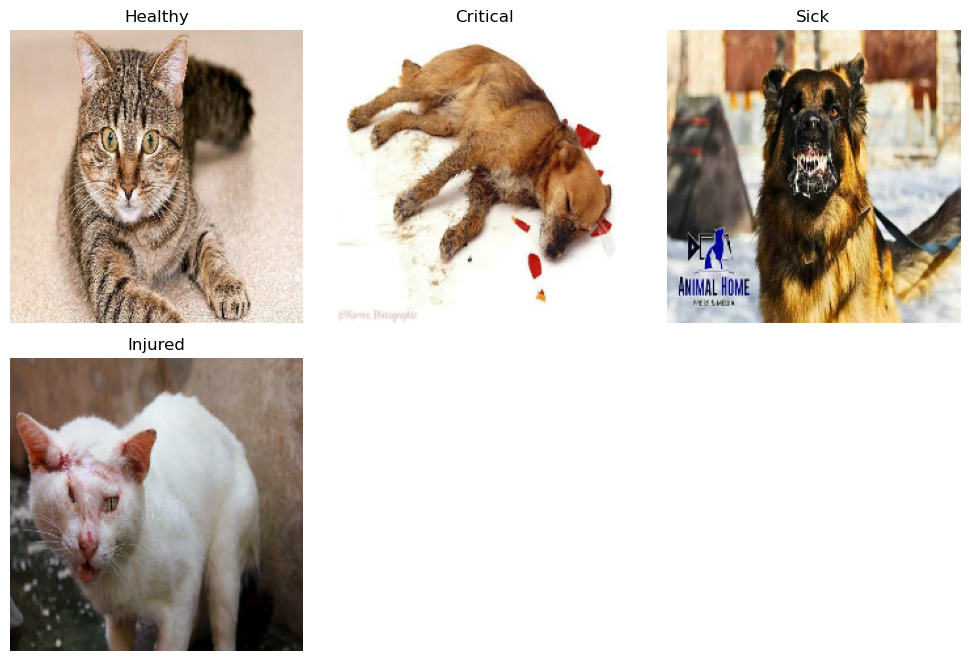

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            train_dataset.class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

NameError: name 'layers' is not defined

In [13]:
import tensorflow as tf
from tensorflow.keras import layers

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [15]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

NameError: name 'MobileNetV2' is not defined

In [16]:
from tensorflow.keras.applications import MobileNetV2

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

from tensorflow.keras import layers
from tensorflow.keras import models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split

In [18]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded successfully")

MobileNetV2 loaded successfully


In [19]:
base_model.trainable = False

In [20]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

image_model = tf.keras.Model(
    inputs,
    outputs
)

NameError: name 'class_names' is not defined

In [21]:
class_names = train_dataset.class_names

print("Classes:", class_names)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [22]:
class_names = ['Critical', 'Healthy', 'Injured', 'Sick']

print("Classes:", class_names)

Classes: ['Critical', 'Healthy', 'Injured', 'Sick']


In [23]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

image_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

image_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [25]:
history = image_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15


C:\Users\senay\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Unknown image file format. One of JPEG, JPEG XL, PNG, GIF, BMP, WebP required.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_8905]

In [26]:
import os
from PIL import Image

DATASET_DIR = "../data/images"

for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(DATASET_DIR, folder)

    if not os.path.isdir(folder_path):
        continue

    print("\nProcessing:", folder)

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        if not os.path.isfile(file_path):
            continue

        try:
            img = Image.open(file_path)
            img = img.convert("RGB")

            base_name = os.path.splitext(filename)[0]
            new_file = os.path.join(
                folder_path,
                base_name + ".jpg"
            )

            # Save as JPG
            img.save(
                new_file,
                "JPEG",
                quality=95
            )

            # Delete original if it wasn't already JPG
            if file_path.lower() != new_file.lower():
                os.remove(file_path)

            print("OK:", filename)

        except Exception as e:
            print("FAILED:", filename)
            print("Error:", e)


Processing: Critical
OK: accident_dog.jpg

Processing: Healthy
FAILED: cat.jpg
Error: Failed to decode frame 0: No codec available
OK: dog.jpg
OK: healthy_cat.webp
OK: healthy_cat1.jpg
OK: healthy_cat2.jpg
OK: healthy_dog.jpg
OK: healthy_dog1.jpg
FAILED: healthy_dog2.avif
Error: Failed to decode frame 0: No codec available

Processing: Injured
OK: injured_cat.jpg
OK: injured_cat1.jpg
OK: injured_cat2.jpg
OK: injured_dog.webp
OK: injured_dog1.jpg
OK: injured_dog2.webp

Processing: Sick
OK: sick_cat.jpg
OK: sick_cat1.webp
OK: sick_dog.jpg


In [27]:
import os

bad_files = [
    "../data/images/Healthy/cat.jpg",
    "../data/images/Healthy/healthy_dog2.avif"
]

for file_path in bad_files:

    if os.path.exists(file_path):
        os.remove(file_path)
        print("Deleted:", file_path)
    else:
        print("Not found:", file_path)

Deleted: ../data/images/Healthy/cat.jpg
Deleted: ../data/images/Healthy/healthy_dog2.avif


In [29]:
import os
from PIL import Image

DATASET_DIR = "../data/images"

for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(DATASET_DIR, folder)

    if not os.path.isdir(folder_path):
        continue

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        if not os.path.isfile(file_path):
            continue

        # Only convert WebP files
        if filename.lower().endswith(".webp"):

            try:
                img = Image.open(file_path)
                img.load()
                img = img.convert("RGB")

                base_name = os.path.splitext(filename)[0]

                new_file = os.path.join(
                    folder_path,
                    base_name + ".jpg"
                )

                img.save(
                    new_file,
                    "JPEG",
                    quality=95
                )

                os.remove(file_path)

                print("Converted:", filename)

            except Exception as e:
                print("FAILED:", filename)
                print(e)

In [30]:
for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(DATASET_DIR, folder)

    if os.path.isdir(folder_path):

        print("\n" + folder)

        for filename in os.listdir(folder_path):
            print("   ", filename)


Critical
    accident_dog.jpg

Healthy
    dog.jpg
    healthy_cat.jpg
    healthy_cat1.jpg
    healthy_cat2.jpg
    healthy_dog.jpg
    healthy_dog1.jpg

Injured
    injured_cat.jpg
    injured_cat1.jpg
    injured_cat2.jpg
    injured_dog.jpg
    injured_dog1.jpg
    injured_dog2.jpg

Sick
    sick_cat.jpg
    sick_cat1.jpg
    sick_dog.jpg


In [31]:
from PIL import Image
import os

for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(DATASET_DIR, folder)

    if not os.path.isdir(folder_path):
        continue

    print("\nChecking:", folder)

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        try:
            with Image.open(file_path) as img:
                img.load()

            print("OK:", filename)

        except Exception as e:
            print("BAD:", filename)
            print("   ", e)


Checking: Critical
OK: accident_dog.jpg

Checking: Healthy
OK: dog.jpg
OK: healthy_cat.jpg
OK: healthy_cat1.jpg
OK: healthy_cat2.jpg
OK: healthy_dog.jpg
OK: healthy_dog1.jpg

Checking: Injured
OK: injured_cat.jpg
OK: injured_cat1.jpg
OK: injured_cat2.jpg
OK: injured_dog.jpg
OK: injured_dog1.jpg
OK: injured_dog2.jpg

Checking: Sick
OK: sick_cat.jpg
OK: sick_cat1.jpg
OK: sick_dog.jpg


In [32]:
from PIL import Image
import os

for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(DATASET_DIR, folder)

    if not os.path.isdir(folder_path):
        continue

    print("\nChecking:", folder)

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        try:
            with Image.open(file_path) as img:
                img.load()

            print("OK:", filename)

        except Exception as e:
            print("BAD:", filename)
            print("   ", e)


Checking: Critical
OK: accident_dog.jpg

Checking: Healthy
OK: dog.jpg
OK: healthy_cat.jpg
OK: healthy_cat1.jpg
OK: healthy_cat2.jpg
OK: healthy_dog.jpg
OK: healthy_dog1.jpg

Checking: Injured
OK: injured_cat.jpg
OK: injured_cat1.jpg
OK: injured_cat2.jpg
OK: injured_dog.jpg
OK: injured_dog1.jpg
OK: injured_dog2.jpg

Checking: Sick
OK: sick_cat.jpg
OK: sick_cat1.jpg
OK: sick_dog.jpg


In [33]:
import tensorflow as tf

DATASET_DIR = "../data/images"

IMG_SIZE = (224, 224)
BATCH_SIZE = 4
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 16 files belonging to 4 classes.
Using 13 files for training.
Found 16 files belonging to 4 classes.
Using 3 files for validation.


In [34]:
for images, labels in train_dataset.take(1):

    print("Image batch shape:", images.shape)
    print("Labels:", labels.numpy())

Image batch shape: (4, 224, 224, 3)
Labels: [1 2 3 2]


In [35]:
for images, labels in validation_dataset.take(1):

    print("Validation image shape:", images.shape)
    print("Validation labels:", labels.numpy())

Validation image shape: (3, 224, 224, 3)
Validation labels: [3 3 3]


In [36]:
Image.open(file_path).verify()

In [37]:
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history = image_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 734ms/step - accuracy: 0.2308 - loss: 1.4844 - val_accuracy: 0.3333 - val_loss: 1.8195
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.3846 - loss: 1.4755 - val_accuracy: 0.3333 - val_loss: 1.7971
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.3846 - loss: 1.3616 - val_accuracy: 0.3333 - val_loss: 1.7549
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.3846 - loss: 1.5602 - val_accuracy: 0.3333 - val_loss: 1.7028
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.1538 - loss: 1.5977 - val_accuracy: 0.3333 - val_loss: 1.6652
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.3077 - loss: 1.4175 - val_accuracy: 0.3333 - val_loss: 1.6416
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.3077 - loss: 1.6316 - val_accuracy: 0.3333 - val_loss: 1.6147
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.3077 - loss: 1.3628 - val_accuracy: 0.3333 - val_loss:

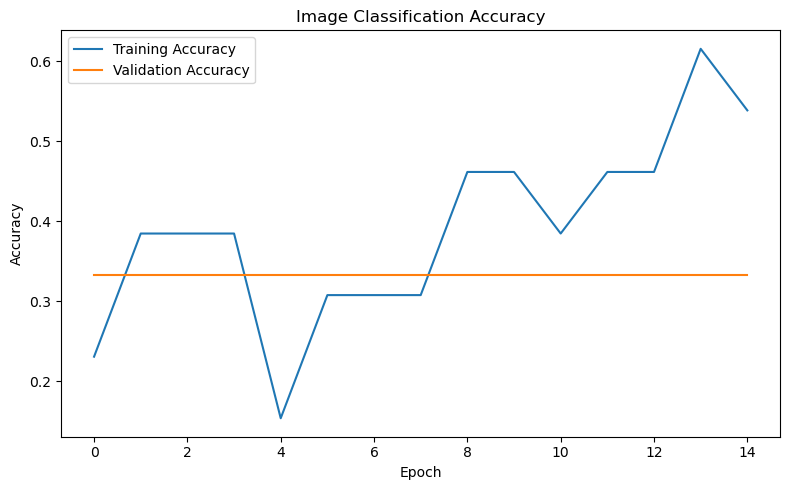

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Image Classification Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.show()